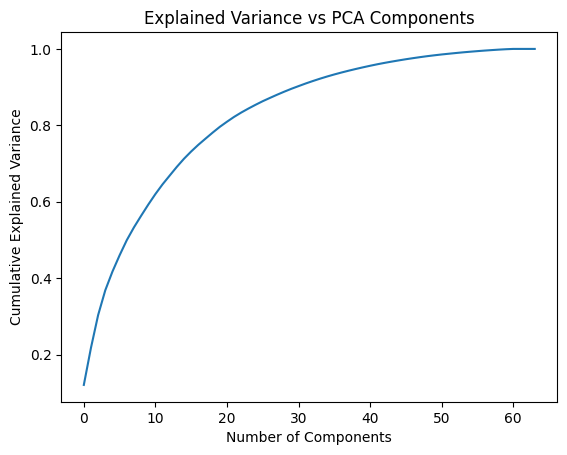

Baseline Accuracy (No PCA): 0.9722222222222222
PCA 2 components → Accuracy: 0.5167, Variance Retained: 0.22
PCA 10 components → Accuracy: 0.8861, Variance Retained: 0.59
PCA 30 components → Accuracy: 0.9611, Variance Retained: 0.90
PCA 50 components → Accuracy: 0.9722, Variance Retained: 0.98


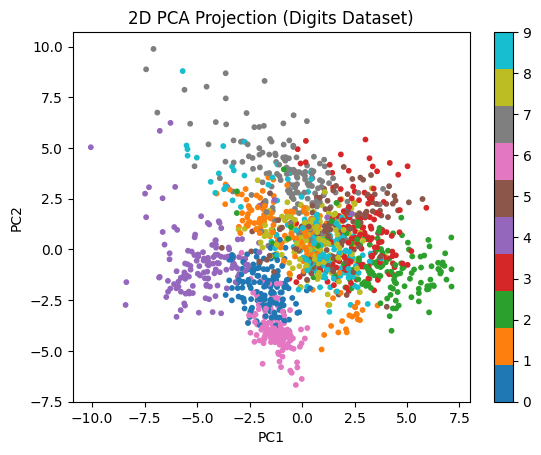

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load built-in digits dataset
digits = load_digits()
X = digits.data
y = digits.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Baseline model (without PCA)
baseline_model = LogisticRegression(max_iter=3000)
baseline_model.fit(X_train_scaled, y_train)
y_pred_base = baseline_model.predict(X_test_scaled)
baseline_accuracy = accuracy_score(y_test, y_pred_base)

# PCA experiments
components = [2, 10, 30, 50]
accuracies = []
variances = []

for n in components:
    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    model = LogisticRegression(max_iter=3000)
    model.fit(X_train_pca, y_train)

    preds = model.predict(X_test_pca)
    acc = accuracy_score(y_test, preds)

    accuracies.append(acc)
    variances.append(pca.explained_variance_ratio_.sum())

# Explained variance plot
pca_full = PCA()
pca_full.fit(X_train_scaled)
cum_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure()
plt.plot(cum_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs PCA Components")
plt.show()

# Accuracy comparison
print("Baseline Accuracy (No PCA):", baseline_accuracy)
for c, acc, var in zip(components, accuracies, variances):
    print(f"PCA {c} components → Accuracy: {acc:.4f}, Variance Retained: {var:.2f}")

# PCA 2D visualization
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_train_scaled)

plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_train, cmap="tab10", s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA Projection (Digits Dataset)")
plt.colorbar()
plt.show()


PCA – Dimensionality Reduction
Objective

Apply Principal Component Analysis (PCA) to reduce feature dimensions and analyze the trade-off between variance retention and model accuracy.

Dataset

Sklearn Digits Dataset

1797 samples, 64 features (8×8 images)

Target classes: digits 0–9

Tools

Python, Scikit-learn, NumPy, Matplotlib

Method

Split data into train and test sets

Scale features using StandardScaler

Train Logistic Regression without PCA (baseline)

Apply PCA with 2, 10, 30, and 50 components

Plot cumulative explained variance

Compare accuracy before and after PCA

Visualize 2D PCA projection

Results

PCA reduces dimensions while preserving most information

Accuracy drops slightly as components decrease

30–50 components retain high variance with good accuracy

Conclusion

PCA effectively compresses features, reduces complexity, and maintains classification performance when an optimal number of components is chosen.